In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
orders = pd.read_csv('olist_orders_dataset.csv')

products = pd.read_csv('olist_products_dataset.csv')

reviews = pd.read_csv('olist_order_reviews_dataset.csv')

items = pd.read_csv('olist_order_items_dataset.csv')

customers = pd.read_csv('olist_customers_dataset.csv')

In [ ]:
print("Orders:", orders.shape)

print("Products:", products.shape)

print("Reviews:", reviews.shape)

print("Items:", items.shape)

print("Customers:", customers.shape)

Orders: (99441, 8)
Products: (32951, 9)
Reviews: (99224, 7)
Items: (112650, 7)
Customers: (99441, 5)


In [ ]:
print("Orders Missing Values")
print(orders.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

print("\nReviews Missing Values")
print(reviews.isnull().sum())

print("\nItems Missing Values")
print(items.isnull().sum())

print("\nCustomers Missing Values")
print(customers.isnull().sum())


Orders Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Products Missing Values
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Reviews Missing Values
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Items Missing Values
order_id               0
or

In [ ]:
print("Orders Duplicates:", orders.duplicated().sum())

print("Products Duplicates:", products.duplicated().sum())

print("Reviews Duplicates:", reviews.duplicated().sum())

print("Items Duplicates:", items.duplicated().sum())

print("Customers Duplicates:", customers.duplicated().sum())

Orders Duplicates: 0
Products Duplicates: 0
Reviews Duplicates: 0
Items Duplicates: 0
Customers Duplicates: 0


In [ ]:
print("Orders")
print(orders.dtypes)

print("\nProducts")
print(products.dtypes)

print("\nReviews")
print(reviews.dtypes)

Orders
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Products
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Reviews
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Data Cleaning Summary

1. Loaded Orders, Products, Reviews, Items and Customers datasets.

2. Checked missing values in all datasets.

3. Identified missing values in product information and review comments.

4. Checked duplicate records and found no duplicate rows.

5. Converted order_purchase_timestamp column into datetime format for time-based analysis.

6. Verified data types for all major datasets before analysis.

In [8]:
sales = pd.merge(
    orders,
    items,
    on='order_id'
)

In [9]:
sales.shape

(112650, 14)

In [10]:
sales['revenue'] = sales['price'] + sales['freight_value']

In [11]:
sales = pd.merge(
    sales,
    products,
    on='product_id'
)

In [12]:
category_revenue = sales.groupby(
    'product_category_name'
)['revenue'].sum().sort_values(
    ascending=False
)

print(category_revenue.head(10))

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241681.72
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
moveis_decoracao           902511.79
utilidades_domesticas      778397.77
cool_stuff                 719329.95
automotivo                 685384.32
ferramentas_jardim         584219.21
Name: revenue, dtype: float64


# Question 1

## Which product category has the highest revenue?

### Answer

The product category with the highest revenue is **beleza_saude**.

Total Revenue Generated: **1441248.07**

This category generated the highest sales revenue among all product categories in the dataset.

In [13]:
sales['month'] = sales['order_purchase_timestamp'].dt.month

In [14]:
monthly_sales = sales.groupby(
    'month'
)['revenue'].sum().sort_values(
    ascending=False
)

print(monthly_sales)

month
5     1735972.77
8     1671513.07
7     1643699.65
3     1587175.41
4     1572120.28
6     1525640.15
2     1273189.58
1     1244490.38
11    1179143.77
12     863566.85
10     826121.21
9      720920.12
Name: revenue, dtype: float64


# Question 2

## Which month generated the highest sales revenue?

### Answer

The month with the highest sales revenue is **May**.

Total Revenue Generated: **1735972.77**

This month recorded the maximum revenue among all months in the dataset.

In [15]:
sales = pd.merge(
    sales,
    customers,
    on='customer_id'
)

In [16]:
state_sales = sales.groupby(
    'customer_state'
)['revenue'].sum().sort_values(
    ascending=False
)

print(state_sales.head(10))

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: revenue, dtype: float64


# Question 3

## Which state generated the highest sales revenue?

### Answer

The state with the highest sales revenue is **SP (São Paulo)**.

Total Revenue Generated: **5921678.12**

This state contributed the highest revenue among all states in the dataset.

In [17]:
average_order_value = sales.groupby(
    'month'
)['revenue'].mean()

print(average_order_value)


month
1     135.816914
2     132.306929
3     141.497317
4     147.492286
5     143.932739
6     143.104788
7     141.564004
8     137.482569
9     149.012013
10    145.315956
11    136.081220
12    136.878562
Name: revenue, dtype: float64


# Question 4

## What is the average order value trend?

### Answer

The average order value varies across different months.

The monthly average revenue values indicate customer purchasing patterns throughout the year.

The trend can be observed from the monthly average order value analysis shown above.

In [18]:
review_distribution = reviews['review_score'].value_counts().sort_index()

print(review_distribution)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


# Question 5

## How are customer review scores distributed?

### Answer

Customer review scores are distributed across ratings from 1 to 5.

The majority of customers gave a rating of **5 stars (57,328 reviews)**, indicating high customer satisfaction.

Lower ratings were comparatively fewer, showing that most customers had a positive shopping experience.

In [19]:
review_distribution = reviews['review_score'].value_counts().sort_index()

print(review_distribution)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


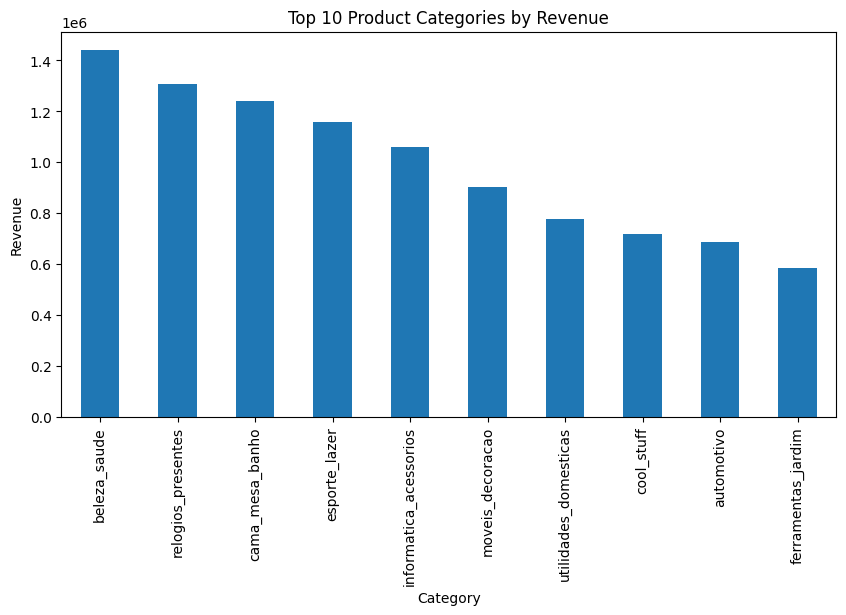

In [20]:
top10_categories = category_revenue.head(10)

plt.figure(figsize=(10,5))
top10_categories.plot(kind='bar')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

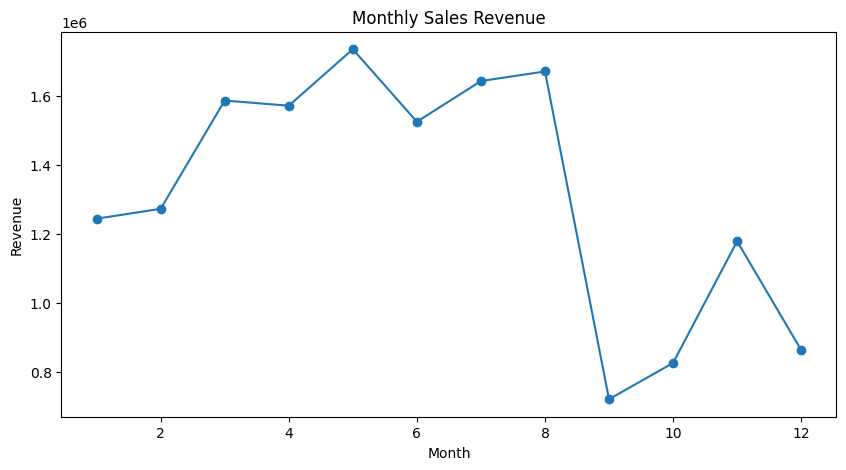

In [21]:
monthly_revenue = sales.groupby(
    'month'
)['revenue'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

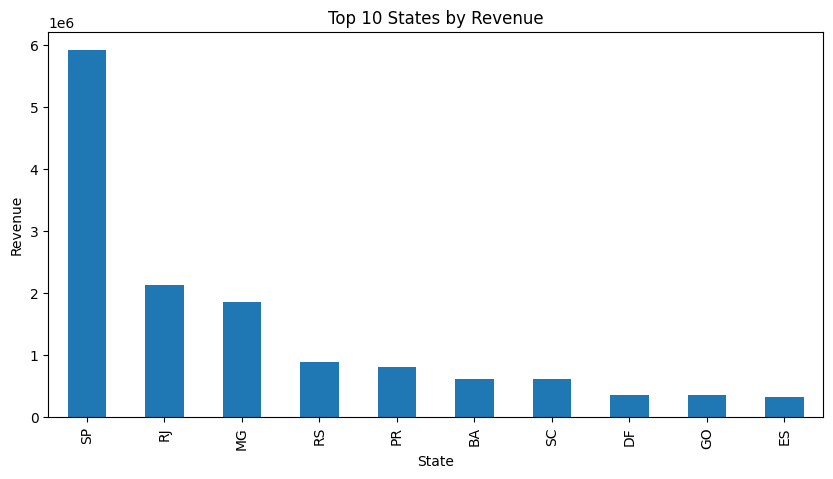

In [22]:
top_states = state_sales.head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

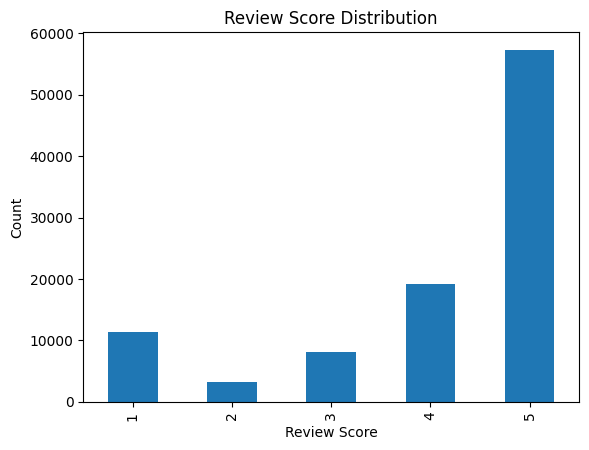

In [23]:
review_distribution.plot(
    kind='bar'
)

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')

plt.show()

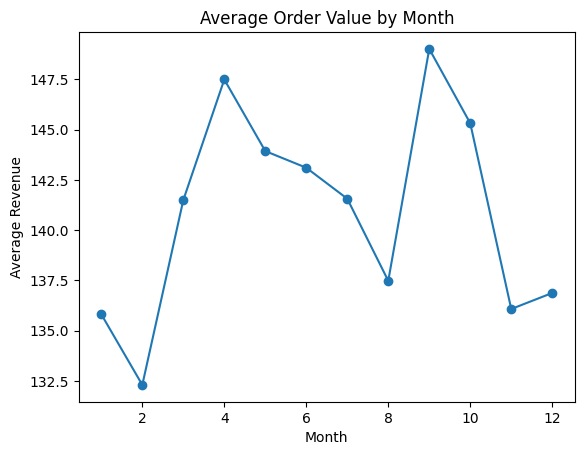

In [24]:
average_order_value.plot(
    kind='line',
    marker='o'
)

plt.title('Average Order Value by Month')
plt.xlabel('Month')
plt.ylabel('Average Revenue')

plt.show()

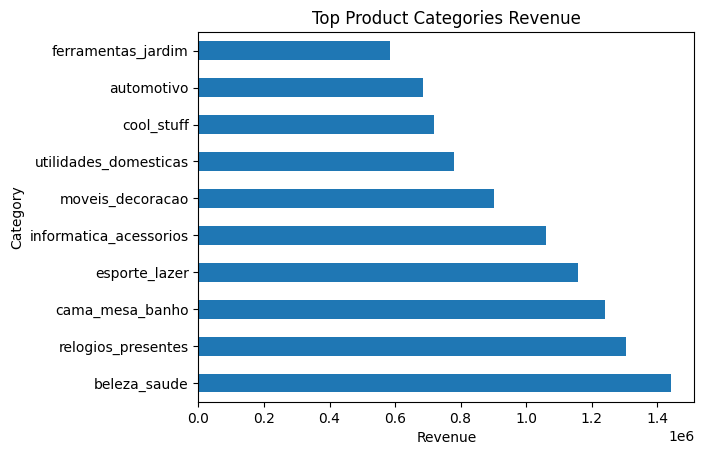

In [25]:
top10_categories.plot(
    kind='barh'
)

plt.title('Top Product Categories Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')

plt.show()

# Dashboard Summary

## Key Performance Indicators (KPIs)

- Total Revenue: 15843553.24

- Total Orders: 98666

- Top Product Category: beleza_saude

- Best Sales Month: May

This dashboard summarizes the overall business performance of the e-commerce platform during the analysis period.

In [27]:
total_revenue = sales['revenue'].sum()

total_orders = sales['order_id'].nunique()

best_month = monthly_sales.idxmax()

top_category = category_revenue.idxmax()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Top Category:", top_category)
month_names = {
    1:"January",
    2:"February",
    3:"March",
    4:"April",
    5:"May",
    6:"June",
    7:"July",
    8:"August",
    9:"September",
    10:"October",
    11:"November",
    12:"December"
}

print("Best Month:", month_names[best_month])

Total Revenue: 15843553.24
Total Orders: 98666
Top Category: beleza_saude
Best Month: May


# Business Insights Report

## Insight 1

The product category **beleza_saude** generated the highest revenue among all categories.

### Recommendation

Increase inventory availability and promotional campaigns for this category to maximize revenue.

---

## Insight 2

May recorded the highest sales revenue among all months.

### Recommendation

Analyze successful campaigns and customer behavior during May and replicate those strategies in other months.

---

## Insight 3

The state **SP (São Paulo)** generated the highest sales revenue.

### Recommendation

Strengthen logistics, advertising, and customer engagement activities in SP to maintain growth.

---

## Insight 4

Average order values varied across months, indicating changing customer purchasing behavior.

### Recommendation

Introduce product bundles and personalized offers to increase average order value.

---

## Insight 5

Most customers gave 4-star and 5-star ratings.

### Recommendation

Maintain product quality and customer support standards to preserve customer satisfaction.

# Most Surprising Finding

The most surprising finding from the analysis was the overwhelming number of 5-star reviews compared to lower ratings.

More than half of the customer reviews were rated 5 stars, indicating a very high level of customer satisfaction.

Despite the large volume of transactions, negative reviews remained relatively low.

This suggests that customers generally had positive experiences with products and services on the platform.